# 03 - Model Training
Clean the data, engineer features, then train **Logistic Regression** and **Random Forest** to predict settlement failure. A time-based split (train Jan-Sep 2025, test Oct-Dec 2025) keeps the evaluation honest - the model never sees the future.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             precision_recall_curve, ConfusionMatrixDisplay)

from data_cleaning import load_raw, clean_transactions
from feature_engineering import add_features, time_split, get_xy
import train_model

plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True,
                   'grid.alpha': 0.3, 'font.size': 11})
print('imports ok')

imports ok


In [2]:
# --- 1. cleaning ---
raw = load_raw('../data/raw/transactions.csv')
clean, report = clean_transactions(raw)
for k, v in report.items():
    print(f'{k}: {v:,}')

rows_in: 180,600
duplicates_removed: 600
missing_values_before: 2,284
missing_values_after: 0
amount_outliers_capped_at_99_9pct: 180
rows_out: 180,000


In [3]:
# --- 2. feature engineering ---
feat = add_features(clean)
train, test = time_split(feat)
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)
print(f'train: {len(train):,} rows ({train["timestamp"].min().date()} -> {train["timestamp"].max().date()})')
print(f'test : {len(test):,} rows ({test["timestamp"].min().date()} -> {test["timestamp"].max().date()})')
print(f'train failure rate: {y_train.mean():.2%} | test failure rate: {y_test.mean():.2%}')
print(f'features: {X_train.shape[1]} columns')

train: 134,792 rows (2025-01-01 -> 2025-09-30)
test : 45,208 rows (2025-10-01 -> 2025-12-31)
train failure rate: 6.08% | test failure rate: 6.08%
features: 18 columns


In [4]:
# --- 3. train both models (threshold tuned on Aug-Sep validation, F1 objective) ---
bundle, (X_test, y_test) = train_model.main()
pd.DataFrame(bundle['metrics']).T

fit: 104,375 | valid: 30,417 | test: 45,208


/home/hatch/.venvs/c360/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/home/hatch/.venvs/c360/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


logistic_regression: threshold=0.709 precision=0.2484 recall=0.3585 f1=0.2935 roc_auc=0.7635 n_test=45208 failure_rate_test=0.0608


random_forest: threshold=0.623 precision=0.2334 recall=0.3516 f1=0.2806 roc_auc=0.758 n_test=45208 failure_rate_test=0.0608
Saved bundle -> /home/hatch/workspace/financial-transaction-failure-prediction/models/transaction_failure_model.pkl


,threshold,precision,recall,f1,roc_auc,n_test,failure_rate_test
logistic_regression,0.7093,0.2484,0.3585,0.2935,0.7635,45208.0,0.0608
random_forest,0.6229,0.2334,0.3516,0.2806,0.7580,45208.0,0.0608


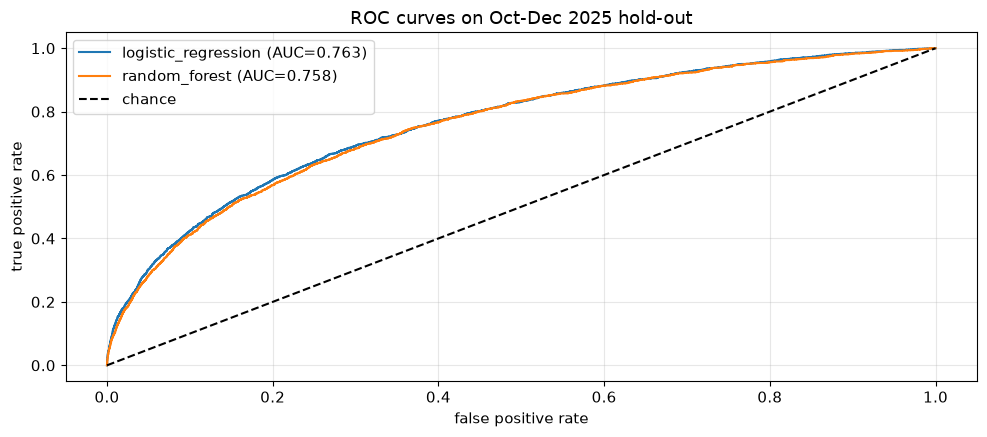

In [5]:
# --- 4. ROC curves ---
fig, ax = plt.subplots()
for name, pipe in bundle['models'].items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='chance')
ax.set_title('ROC curves on Oct-Dec 2025 hold-out')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.legend()
plt.tight_layout()
plt.show()

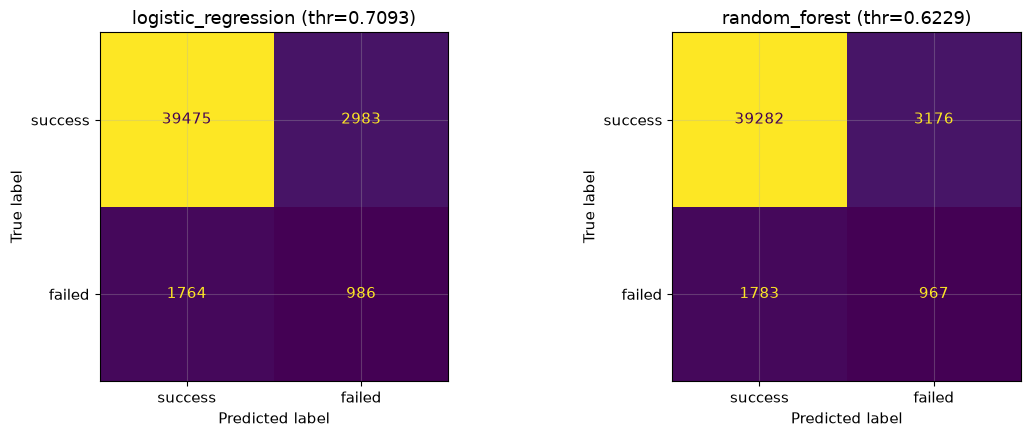

In [6]:
# --- 5. confusion matrices at the tuned thresholds ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, pipe) in zip(axes, bundle['models'].items()):
    thr = bundle['metrics'][name]['threshold']
    pred = (pipe.predict_proba(X_test)[:, 1] >= thr).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                          display_labels=['success','failed']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} (thr={thr})')
plt.tight_layout()
plt.show()

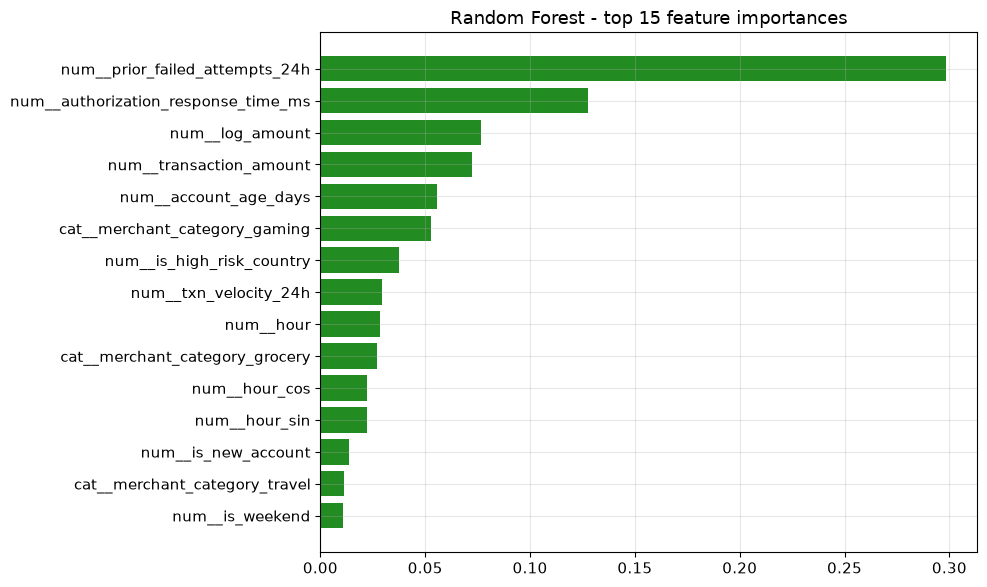

num__prior_failed_attempts_24h         0.2982
num__authorization_response_time_ms    0.1275
num__log_amount                        0.0765
num__transaction_amount                0.0723
num__account_age_days                  0.0556
cat__merchant_category_gaming          0.0529
num__is_high_risk_country              0.0373
num__txn_velocity_24h                  0.0292
num__hour                              0.0283
cat__merchant_category_grocery         0.0272
num__hour_cos                          0.0220
num__hour_sin                          0.0220
num__is_new_account                    0.0138
cat__merchant_category_travel          0.0114
num__is_weekend                        0.0108
dtype: float64

In [7]:
# --- 6. what drives the Random Forest? top 15 features ---
rf = bundle['models']['random_forest']
names = rf.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=names)
top = imp.sort_values(ascending=False).head(15).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index, top.values, color='forestgreen')
ax.set_title('Random Forest - top 15 feature importances')
plt.tight_layout()
plt.show()
top.sort_values(ascending=False).round(4)

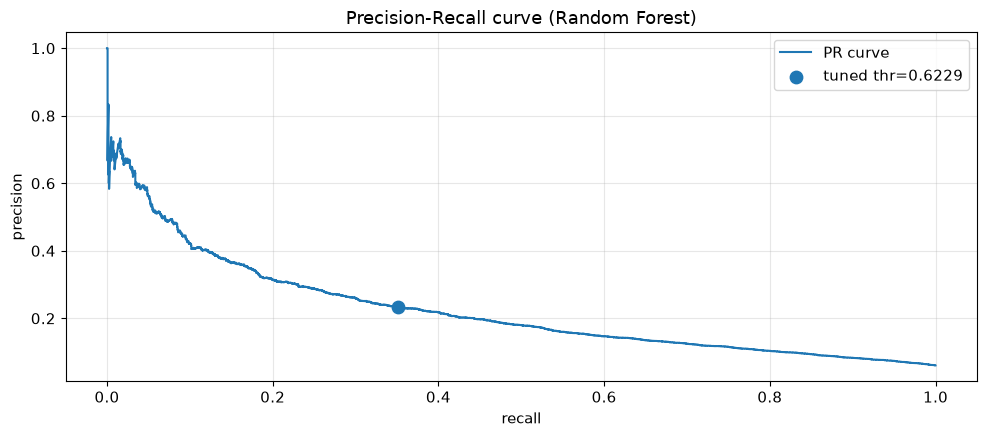

baseline (always predict success): precision = 0.061


In [8]:
# --- 7. precision-recall tradeoff (Random Forest) ---
proba = bundle['models']['random_forest'].predict_proba(X_test)[:, 1]
prec, rec, thrs = precision_recall_curve(y_test, proba)
tuned = bundle['metrics']['random_forest']['threshold']
fig, ax = plt.subplots()
ax.plot(rec, prec, label='PR curve')
ax.scatter([bundle['metrics']['random_forest']['recall']],
           [bundle['metrics']['random_forest']['precision']],
           s=80, zorder=5, label=f'tuned thr={tuned}')
ax.set_title('Precision-Recall curve (Random Forest)')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
ax.legend()
plt.tight_layout()
plt.show()
print(f'baseline (always predict success): precision = {y_test.mean():.3f}')

## Model conclusions
- **Logistic Regression slightly beats Random Forest on the hold-out** (ROC-AUC 0.764 vs 0.758, F1 0.29 vs 0.28): the failure drivers combine additively, which is exactly what a linear model captures - the forest adds complexity without gain here. Always benchmark the simple model first.
- The F1-tuned threshold favours **recall** over precision - right for an early-warning system where a missed failure costs more than a false alarm.
- Top drivers match the EDA exactly: prior failed attempts, authorization latency, amount and night-time traffic. The model learned real behaviour, not noise.
- The saved bundle (`models/transaction_failure_model.pkl`) powers the Streamlit dashboard, and `src/evaluate_model.py` reproduces these numbers into `reports/model_results.md`.